In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
mail_data = pd.read_csv("mail_data.csv")
mail_data.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
mail_data.shape

(5572, 2)

In [6]:
mail_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [7]:
mail_data.isnull().sum()

,0
Category,0
Message,0


In [8]:
mail_data = mail_data.fillna("")

mail_data.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
mail_data["Category"].value_counts()

,count
Category,
ham,4825
spam,747


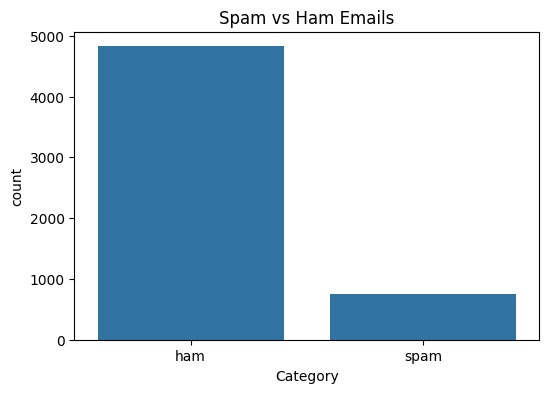

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(x="Category", data=mail_data)

plt.title("Spam vs Ham Emails")

plt.show()

In [11]:
mail_data.describe(include="object")

,Category,Message
count,5572,5572
unique,2,5157
top,ham,"Sorry, I'll call later"
freq,4825,30


In [12]:
mail_data.replace({"Category":{"spam":0,"ham":1}}, inplace=True)

mail_data.head()

/tmp/ipykernel_6937/1508208940.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mail_data.replace({"Category":{"spam":0,"ham":1}}, inplace=True)


,Category,Message
0,1,"Go until jurong point, crazy.. Available only ..."
1,1,Ok lar... Joking wif u oni...
2,0,Free entry in 2 a wkly comp to win FA Cup fina...
3,1,U dun say so early hor... U c already then say...
4,1,"Nah I don't think he goes to usf, he lives aro..."


In [13]:
X = mail_data["Message"]
y = mail_data["Category"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [15]:
vectorizer = TfidfVectorizer(
    min_df=1,
    stop_words="english",
    lowercase=True
)

In [16]:
X_train_features = vectorizer.fit_transform(X_train)

X_test_features = vectorizer.transform(X_test)

In [17]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_features, y_train)

LogisticRegression(max_iter=1000)

In [18]:
train_prediction = model.predict(X_train_features)

train_accuracy = accuracy_score(y_train, train_prediction)

print("Training Accuracy :", train_accuracy)

Training Accuracy : 0.9683643706529056


In [19]:
test_prediction = model.predict(X_test_features)

test_accuracy = accuracy_score(y_test, test_prediction)

print("Testing Accuracy :", test_accuracy)

Testing Accuracy : 0.9596412556053812


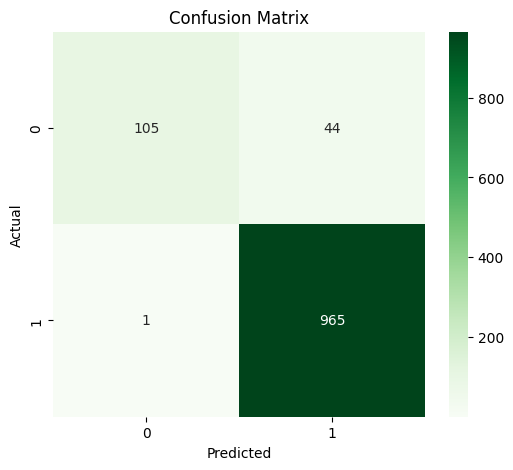

In [20]:
cm = confusion_matrix(y_test, test_prediction)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [21]:
print(classification_report(y_test, test_prediction))

              precision    recall  f1-score   support

           0       0.99      0.70      0.82       149
           1       0.96      1.00      0.98       966

    accuracy                           0.96      1115
   macro avg       0.97      0.85      0.90      1115
weighted avg       0.96      0.96      0.96      1115



In [22]:
accuracy = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "Accuracy": [train_accuracy, test_accuracy]
})

accuracy

,Dataset,Accuracy
0,Training,0.968364
1,Testing,0.959641


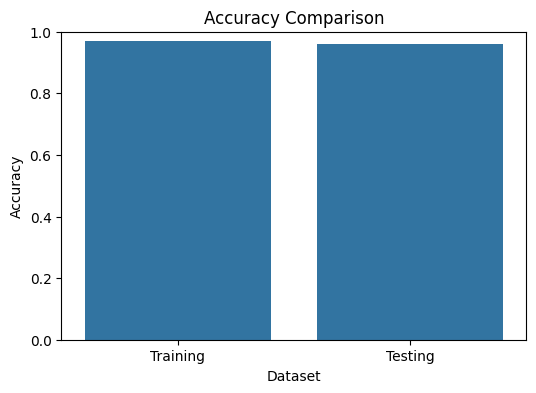

In [23]:
plt.figure(figsize=(6,4))

sns.barplot(data=accuracy, x="Dataset", y="Accuracy")

plt.ylim(0,1)

plt.title("Accuracy Comparison")

plt.show()

In [24]:
input_mail = ["Congratulations! You have won a free iPhone. Click the link now to claim your prize."]

In [25]:
input_data = vectorizer.transform(input_mail)

prediction = model.predict(input_data)

print(prediction)

[0]


In [26]:
if prediction[0] == 0:
    print("Spam Mail")
else:
    print("Ham Mail")

Spam Mail


In [27]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": test_prediction
})

comparison.head(10)

,Actual,Predicted
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1
5,0,0
6,1,1
7,1,1
8,1,1
9,0,0


In [28]:
import pickle

pickle.dump(model, open("spam_mail_model.pkl", "wb"))
pickle.dump(vectorizer, open("tfidf_vectorizer.pkl", "wb"))

In [29]:
loaded_model = pickle.load(open("spam_mail_model.pkl", "rb"))

sample = vectorizer.transform(["Hey! Are we meeting today at 5 PM?"])

print(loaded_model.predict(sample))

[1]
